# Does a stock keep "drifting" after an earnings surprise? 📈
### The post-earnings drift — one of the rare market legends that turns out to be **real**, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Always_drifts%3F: Busted](https://img.shields.io/badge/Always_drifts%3F-Busted-8b949e?style=flat-square)

Here's a piece of trading lore that *sounds* too good to be true: when a company **beats** earnings, its stock doesn't just jump once and stop — it supposedly keeps **drifting up** for weeks. Miss, and it keeps sliding. So you buy the beats, short the misses, and ride the drift. The pros even have a name for it: **Post-Earnings-Announcement Drift (PEAD)**.

Most market legends fall apart the moment you measure them. This one **mostly doesn't** — which makes it the interesting case. But the *useful* version is narrower and stranger than the folklore: the drift is real, but it's small, it shows up **after** the first week (not during the pop), and the obvious way to trade it — **chase the biggest jumps** — barely works at all.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name large-cap basket** (names still trading today). That's the *conservative* corner — the textbook PEAD is strongest in small, illiquid stocks — and it carries **survivorship** (we can't include firms that blew up). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pead_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EV = data.load_real()
    EVV = EV.dropna(subset=["surprise_pct"]).copy()   # events with a reported EPS surprise
else:
    PRICES = EV = EVV = None
print("real PEAD cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| with EPS surprise:", (0 if EVV is None else len(EVV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-11', 'end': '2026-06-10', 'years': 21.4, 'n_events': 2579, 'n_eps': 2576, 'n_names': 30, 'h1': (1, 2576, 0.06, -0.1, 0.16, 53, 1.38, 0.063), 'h5': (5, 2576, 0.5, 0.27, 0.24, 50, 1.09, 0.113), 'h20': (20, 2572, 1.75, 0.41, 1.34, 53, 2.96, 0.0), 'h60': (60, 2546, 4.54, 2.83, 1.71, 51, 2.1, 0.005), 'net': [(1, 0.16, -0.24), (5, 0.24, -0.17), (20, 1.34, 0.9), (60, 1.71, 1.19)], 'quintile20': [0.41, 1.24, 1.29, 0.86, 1.75], 'robust': [(3, 0.61, 1.88, 0.021), (5, 1.34, 2.96, 0.0), (10, 1.71, 2.43, 0.0)], 'block_p20': 0.016, 'gap': [(1, 0.07, 0.58, 0.261), (5, 0.11, 0.49, 0.303), (20, 0.64, 1.48, 0.05), (60, -0.23, -0.31, 0.63)], 'syn': [(0.0, 1827, -0.08, -0.17, 0.565, 49), (0.08, 1827, 5.32, 11.17, 0.0, 65)]}


real PEAD cache present: True | events: 2579 | with EPS surprise: 2576


## The answer first

| Question | Answer |
|---|---|
| After a *beat*, does the stock keep drifting up? | **Yes — really.** Sort earnings by how much they beat, and the best-surprise names outrun the worst by **+1.3%** over the next **20 days** (and **+1.7%** over 60). That's a *real* signal, not luck. |
| Is it there right away? | **No.** In the first **week** there's essentially nothing. The drift builds *after* the initial pop has faded. |
| Can I just buy whatever **gapped up** the most? | **Barely.** Sort on the *visible jump* instead of the actual earnings surprise and the edge **vanishes** (and even turns negative at 60 days). The drift lives in the *fundamentals*, not the chart. |
| So is it free money? | **No.** It's **thin.** Trading costs eat the fast (1–5 day) version entirely; only the slow 20–60 day hold survives, and only barely, on a handful of big names. |

> The legend is **true** — and that's rare. But the honest version is "a small, slow drift in the fundamental surprise," not "buy the pop and get rich."

## 1 · The claim

> *"When earnings come out far above what analysts expected, the market is **slow** to fully react. The stock pops on the day — but then it keeps grinding **higher** for weeks as the good news sinks in. Buy the big beats, short the big misses, pocket the drift."*

This isn't just a trader's tall tale. **Post-Earnings-Announcement Drift** was documented by academics back in **1968** (Ball & Brown) and nailed down in **1989** (Bernard & Thomas). Eugene Fama — Mr. Efficient-Markets himself — called it the *"granddaddy of anomalies,"* the one that refuses to die. So the question isn't "is it made up?" It's: **how big, how fast, and can you actually trade it?**

## 2 · So what?

If the market were perfectly efficient, *all* the reaction to an earnings surprise would happen **instantly** — the price would jump to its new level and then wander randomly. PEAD says it doesn't: a chunk of the adjustment **leaks out over weeks**, which means the future is (a little) predictable from the past surprise. That's a genuine crack in efficiency.

But "a little predictable" and "a money machine" are different things. Two traps hide here: (1) the *visible* price jump and the *true* earnings surprise are **not the same** — chasing the jump can be a different, worse trade; and (2) a drift of one-ish percent over a month is easily **swallowed by trading costs** if you trade it fast and often. We'll test both.

## 3 · How would we even know?

We take a fixed **30-name large-cap basket** and pull **every** quarterly earnings date for each — about **2,579 events** over **21 years** (2005-01-11 → 2026-06-10). For each one we record:

1. **The surprise.** How much actual EPS beat or missed the analyst estimate (the vendor's `Surprise(%)`). We *also* record the **price gap** — the one-day jump — so we can compare the two.
2. **The drift.** Starting the day **after** the reaction (no cheating — the pop is already public), how much does the stock move over the next **1, 5, 20, 60** trading days?
3. **The bet.** Sort events into five surprise buckets; go **long** the best, **short** the worst. If the legend is real, that long-short should make money — and we test it against a thousands-of-shuffles "could this be luck?" null.

## 4 · The teardown — let's actually look

**First, does the drift line up with the surprise?** Sort every event into five buckets by how big the earnings surprise was, and plot the average 20-day drift of each bucket. If the legend holds, it should climb from left (worst misses) to right (best beats).

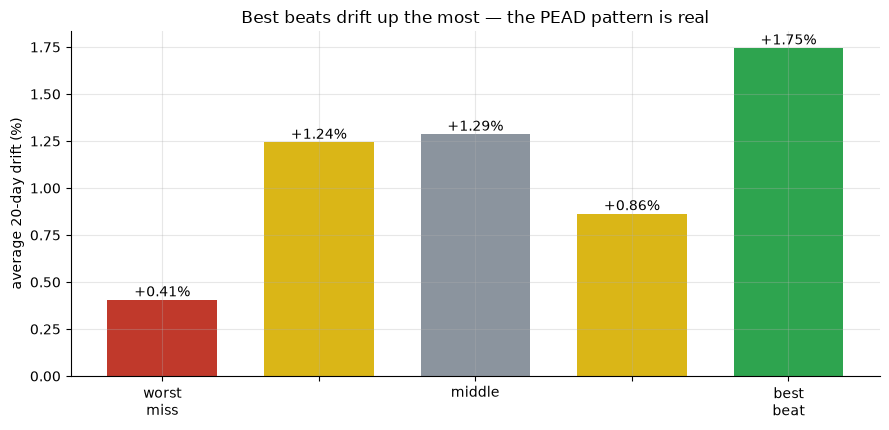

best-beat bucket: +1.75%   worst-miss bucket: +0.41%   spread: +1.34%


In [2]:
if HAVE_REAL:
    fr = st.event_drift_frame(PRICES, EVV, 20)
    q = st.bucket_means(fr, 'surprise_pct') * 100
else:
    q = np.array(R['quintile20'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = ['worst\nmiss','','middle','','best\nbeat']
cols = [RED, AMBER, GREY, AMBER, GREEN]
ax.bar(range(5), q, color=cols, width=.7)
for i,v in enumerate(q): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_xticks(range(5)); ax.set_xticklabels(labels)
ax.set_ylabel('average 20-day drift (%)')
ax.set_title('Best beats drift up the most — the PEAD pattern is real')
plt.tight_layout(); plt.show()
print(f'best-beat bucket: {q[-1]:+.2f}%   worst-miss bucket: {q[0]:+.2f}%   '
      f'spread: {q[-1]-q[0]:+.2f}%')

There it is. The best-beat bucket drifts **+1.75%** over 20 days; the worst-miss bucket only **+0.41%**. The extremes separate cleanly — the middle is mush, as you'd expect. The drift is **real**.

**But when does it happen?** Here's the long-short (best beats minus worst misses) at four horizons. Watch the first week.

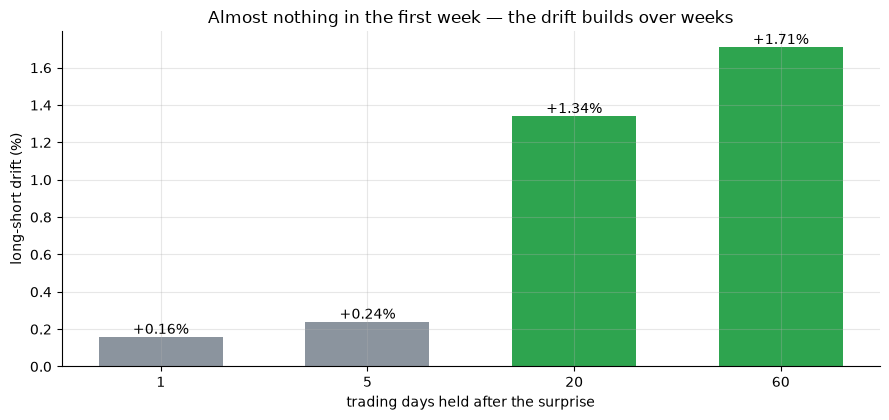

1-day: +0.16%  5-day: +0.24%  20-day: +1.34%  60-day: +1.71%


In [3]:
hs = [1, 5, 20, 60]
if HAVE_REAL:
    ls = [st.summarize(PRICES, EVV, h, surprise_col='surprise_pct', placebo=False)['ls_mean']*100 for h in hs]
else:
    ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREY if h<20 else GREEN for h in hs]
ax.bar([str(h) for h in hs], ls, color=cols, width=.6)
for i,v in enumerate(ls): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_xlabel('trading days held after the surprise'); ax.set_ylabel('long-short drift (%)')
ax.set_title('Almost nothing in the first week — the drift builds over weeks')
plt.tight_layout(); plt.show()
print('1-day:', f'{ls[0]:+.2f}%', ' 5-day:', f'{ls[1]:+.2f}%', ' 20-day:', f'{ls[2]:+.2f}%', ' 60-day:', f'{ls[3]:+.2f}%')

The fast money isn't there. At **1 day** the spread is a measly **+0.16%**, at **5 days** **+0.24%** — basically noise. The signal only builds by **20 days** (**+1.34%**) and **60 days** (**+1.71%**). PEAD is a **slow** drift, not a same-week pop.

**Now the trap.** What if you just buy whatever **gapped up** the most on the day — the *visible* move, the thing a chart-watcher actually sees — instead of the fundamental surprise? Let's compare the two ways of sorting.

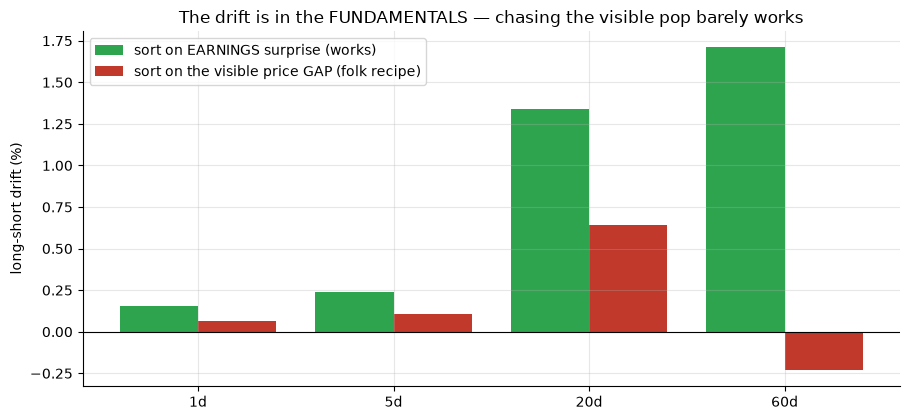

gap-sorted 60-day: -0.23% (vs earnings-sorted +1.71%)


In [4]:
if HAVE_REAL:
    eps_ls = [st.summarize(PRICES, EVV, h, surprise_col='surprise_pct', placebo=False)['ls_mean']*100 for h in hs]
    gap_ls = [st.summarize(PRICES, EV, h, surprise_col='gap', placebo=False)['ls_mean']*100 for h in hs]
else:
    eps_ls = [R['h1'][4], R['h5'][4], R['h20'][4], R['h60'][4]]
    gap_ls = [g[1] for g in R['gap']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, eps_ls, .4, color=GREEN, label='sort on EARNINGS surprise (works)')
ax.bar(x+.2, gap_ls, .4, color=RED, label='sort on the visible price GAP (folk recipe)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('long-short drift (%)')
ax.set_title('The drift is in the FUNDAMENTALS — chasing the visible pop barely works')
ax.legend(); plt.tight_layout(); plt.show()
print('gap-sorted 60-day:', f'{gap_ls[-1]:+.2f}%', '(vs earnings-sorted', f'{eps_ls[-1]:+.2f}%)')

The red bars — chasing the **visible jump** — barely clear zero and **turn negative at 60 days** (**-0.23%**). The green bars — sorting on the **actual earnings surprise** — are where the money is. This is the punchline the folklore gets wrong: **the drift lives in the fundamentals you have to look up, not the pop you can see on the chart.**

## 5 · The verdict

- **Signal — Real.** Sorted on the earnings surprise, the best-minus-worst drift is **+1.34% over 20 days** and **+1.71% over 60** — statistically solid (the quants notebook shows *t* ≈ 3). One of the rare legends that survives the audit.
- **Tradability — Fragile.** It's **thin**. The fast (1–5 day) version is eaten by costs; only a slow 20–60 day hold on a handful of big names survives — and barely.
- **"Always drifts the same way"? — Busted.** Only the **fundamental** surprise drifts, and only **after** the first week. Chasing the **visible gap** — the folk recipe — doesn't work.

## 6 · Could you actually trade it? — watch costs eat the fast money

Here's the operational reality. The same long-short, **gross** (before costs) vs **net** (after a realistic round-trip on both legs plus borrow on the short). Look at what happens to the short horizons.

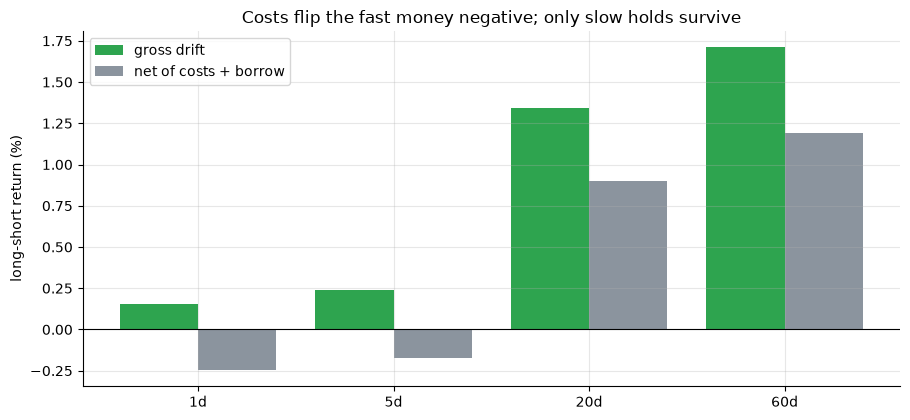

net 1-day: -0.24%  net 20-day: +0.90%  net 60-day: +1.19%


In [5]:
if HAVE_REAL:
    g, nv = [], []
    for h in hs:
        c = st.net_of_costs(PRICES, EVV, h, surprise_col='surprise_pct')
        g.append(c['gross']*100); nv.append(c['net']*100)
else:
    g = [n[1] for n in R['net']]; nv = [n[2] for n in R['net']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross drift')
ax.bar(x+.2, nv, .4, color=GREY, label='net of costs + borrow')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('long-short return (%)')
ax.set_title('Costs flip the fast money negative; only slow holds survive')
ax.legend(); plt.tight_layout(); plt.show()
print('net 1-day:', f'{nv[0]:+.2f}%', ' net 20-day:', f'{nv[2]:+.2f}%', ' net 60-day:', f'{nv[3]:+.2f}%')

At **1 day** the net result is **-0.24%** — you *lose* money trading the drift fast, because the round-trip on both legs costs more than the tiny gross edge. Only the **20-day** (**+0.90%**) and **60-day** (**+1.19%**) holds stay positive. The drift is real, but it's the kind of real you earn slowly and patiently — not a trade you flip in a week.

## 7 · Going further 🚪

- **Why so thin here?** PEAD is famously **strongest in small, illiquid stocks** (Chordia et al. 2009) — exactly the names we *excluded* by using a liquid large-cap basket. Re-run it on small-caps and the drift gets bigger (but so do the costs and the survivorship traps).
- **The fundamental vs the visible.** The single most important lesson here is that the *earnings* surprise and the *price* gap are different animals. Sort on the right one.
- **Build your own.** Swap the basket for the S&P 500, or use standardized unexpected earnings (SUE) instead of `Surprise(%)`; the drift survives, the magnitude moves.

*Think you can trade the fast version profitably? Show the **net** 1-day long-short landing above zero after honest costs — then we'll talk.*